/House Price Prediction


/House Price Prediction


## Project Notes

This notebook builds a house price prediction model using the Ames Housing dataset.

### Key issues to document
- Training and test preprocessing must be identical.
- Do not drop rows from `test`; the submission file must have one prediction per original test row.
- Use the processed `X_test` matrix for prediction, not the raw `test` DataFrame.
- Keep feature columns aligned between train and test after encoding.
- The final output column should be `SalePrice` for Kaggle submissions.

### Fixes to make
1. Consolidate preprocessing so `train_clean` and `test_clean` are handled with the same rules.
2. Use train-derived statistics (median/mode) to fill missing values in `test`.
3. One-hot encode combined train+test data, then split back into `X_train` and `X_test`.
4. Train the final model on `X_train`, then predict on `X_test`.
5. Save submission with `Id` and `SalePrice`.

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [72]:
df = pd.read_csv('../data/raw/train.csv')
test = pd.read_csv('../data/raw/test.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [73]:
df.shape
test.shape

(1459, 80)

In [74]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [75]:
df.isna().sum().sort_values(ascending=False)


PoolQC           1453
MiscFeature      1406
Alley            1369
Fence            1179
MasVnrType        872
                 ... 
MoSold              0
YrSold              0
SaleType            0
SaleCondition       0
SalePrice           0
Length: 81, dtype: int64

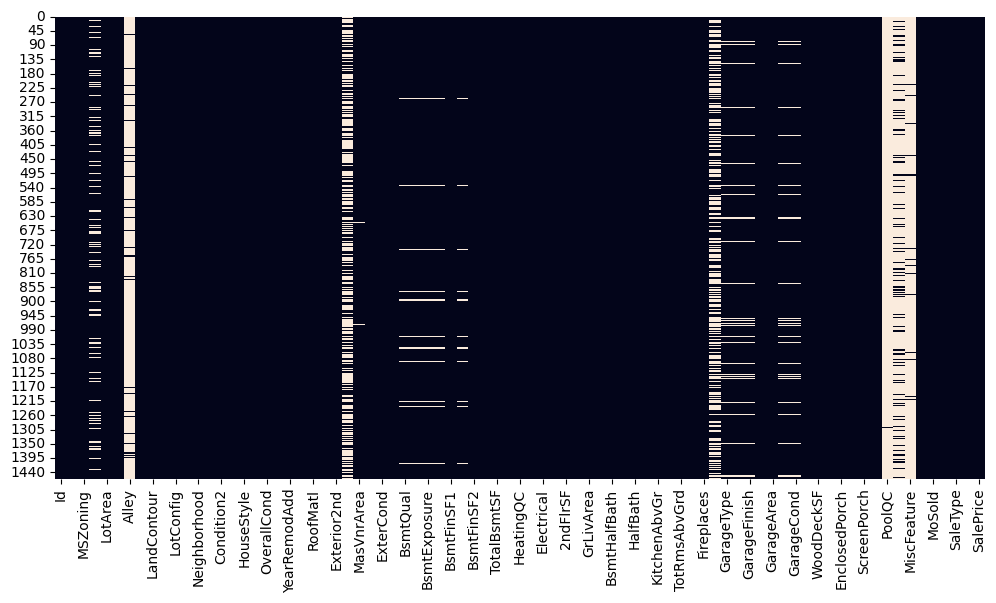

In [76]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isna(),cbar=False)
plt.show()

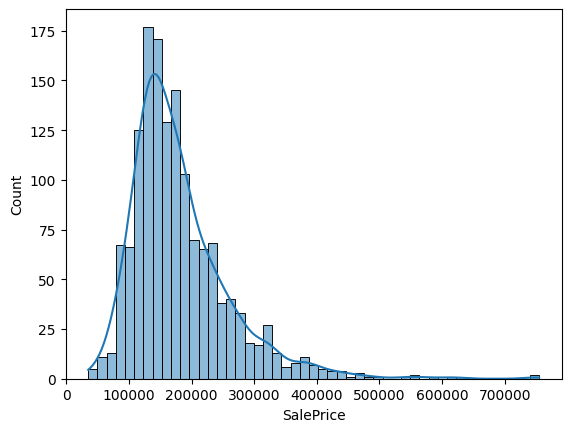

In [77]:
sns.histplot(df['SalePrice'],kde=True)
plt.show()

In [78]:
df['SalePrice'].skew()

np.float64(1.8828757597682129)

In [79]:
corr = df.corr(numeric_only=True)

<Axes: >

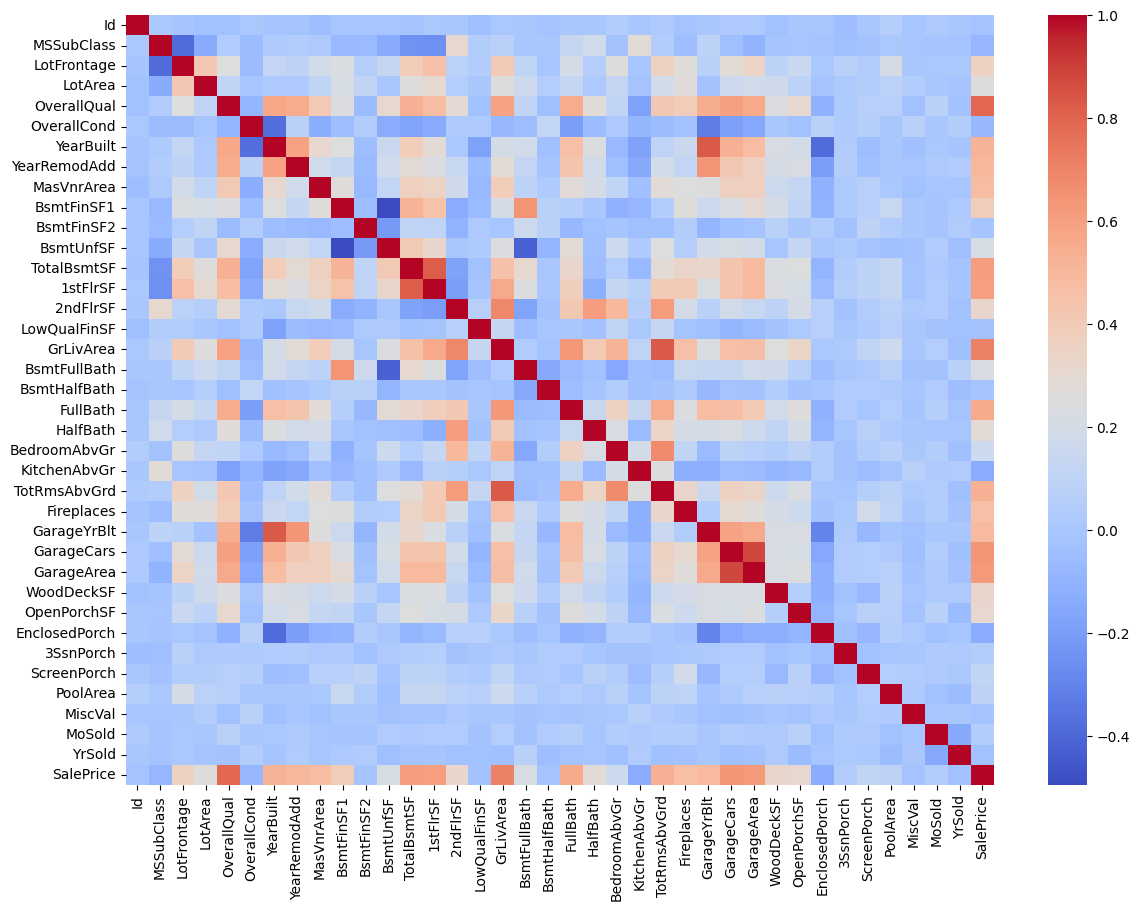

In [80]:
plt.figure(figsize=(14,10))
sns.heatmap(corr,cmap="coolwarm")

In [81]:
corr['SalePrice'].sort_values(ascending=False)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

<Axes: xlabel='SalePrice', ylabel='OverallQual'>

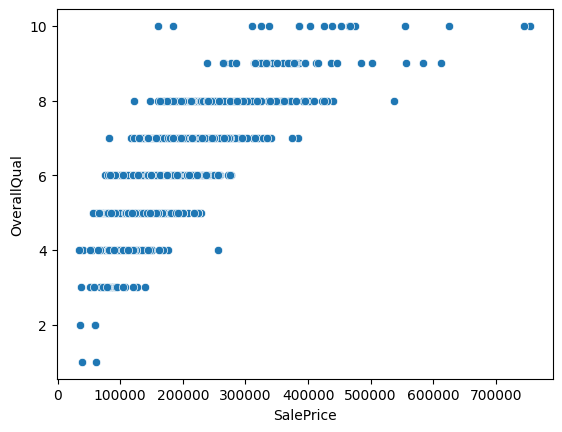

In [82]:
sns.scatterplot(x=df['SalePrice'],y=df['OverallQual'])


<Axes: xlabel='SalePrice', ylabel='GrLivArea'>

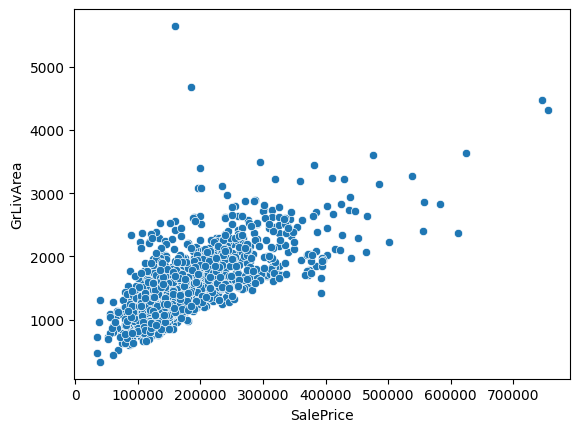

In [83]:
sns.scatterplot(x=df['SalePrice'],y=df['GrLivArea'])


<Axes: xlabel='SalePrice', ylabel='GarageCars'>

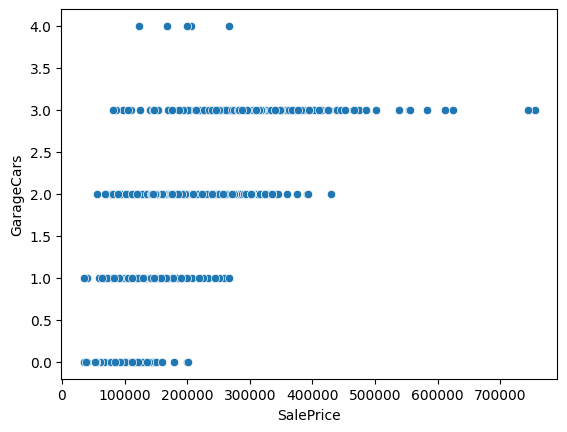

In [84]:
sns.scatterplot(x=df['SalePrice'],y=df['GarageCars'])


<Axes: xlabel='SalePrice', ylabel='GarageArea'>

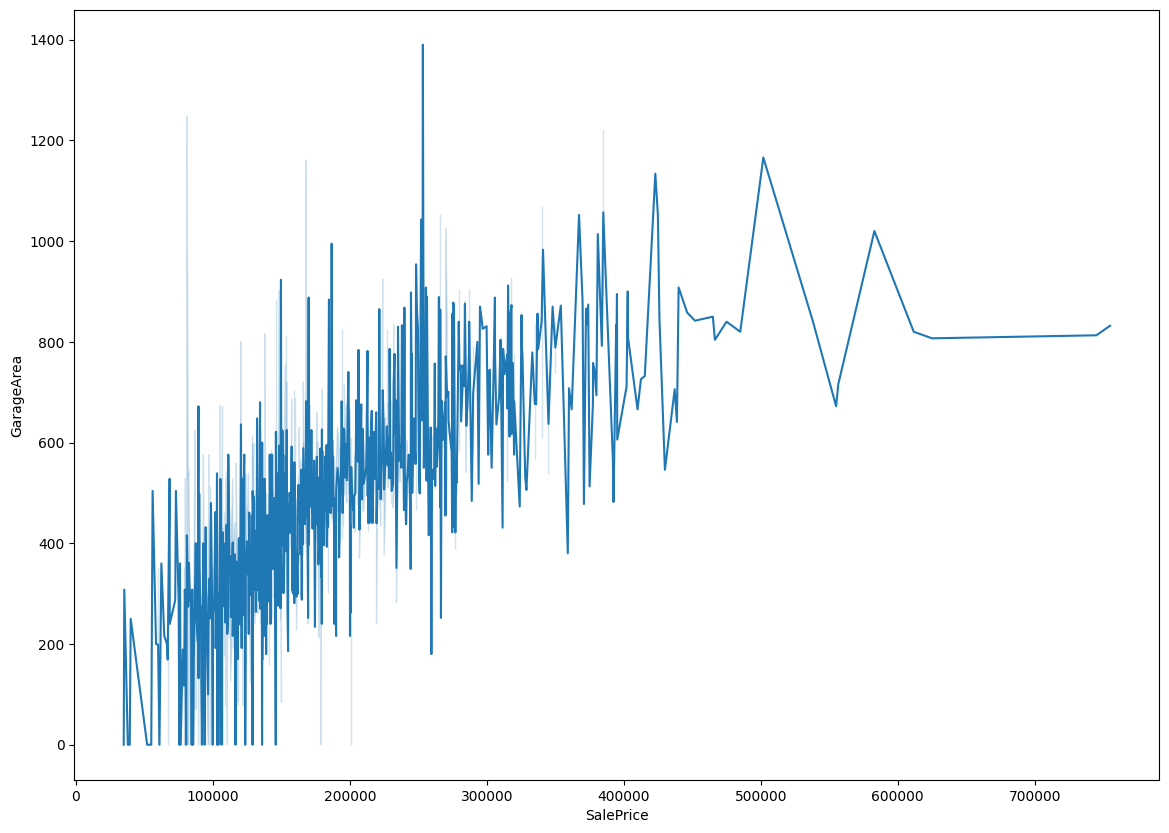

In [85]:
plt.figure(figsize=(14,10))
sns.lineplot(x=df['SalePrice'],y=df['GarageArea'])

In [86]:
cat_df = df.select_dtypes('object','category').nunique()

C:\Users\Kendie\AppData\Local\Temp\ipykernel_13348\3578653307.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_df = df.select_dtypes('object','category').nunique()


In [87]:
df.groupby(cat_df)['SalePrice'].mean().sort_values(ascending=False)

Series([], Name: SalePrice, dtype: float64)

<Axes: xlabel='Neighborhood', ylabel='SalePrice'>

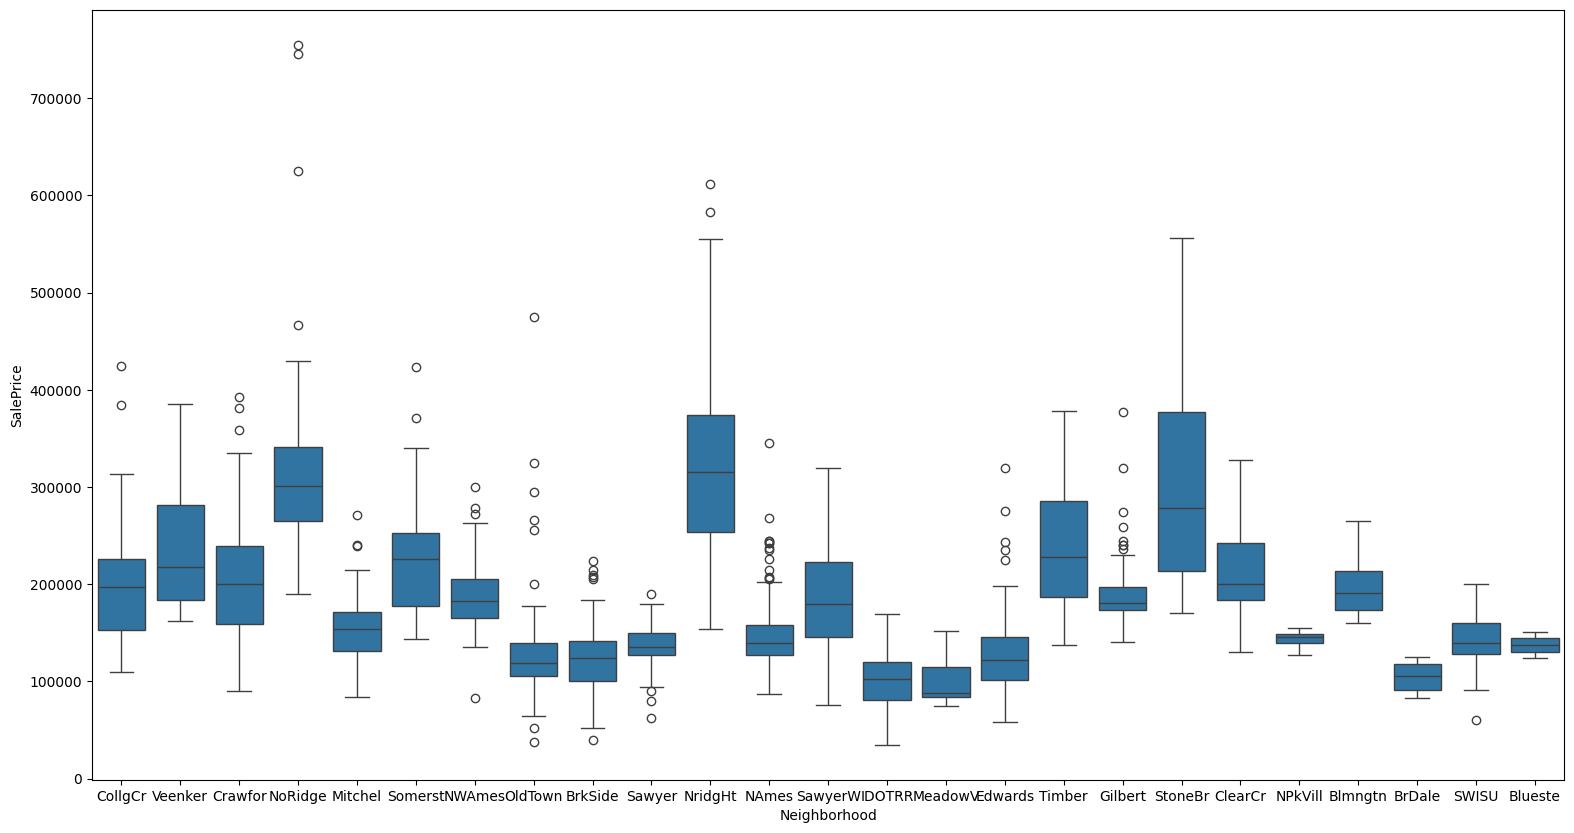

In [88]:
plt.figure(figsize=(19,10))
sns.boxplot(x=df['Neighborhood'],y=df['SalePrice'])

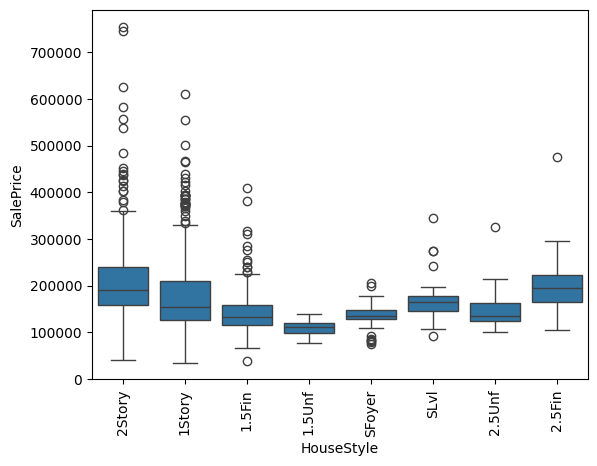

In [89]:
sns.boxplot(x=df['HouseStyle'],y=df['SalePrice'])
plt.xticks(rotation=90)
plt.show()

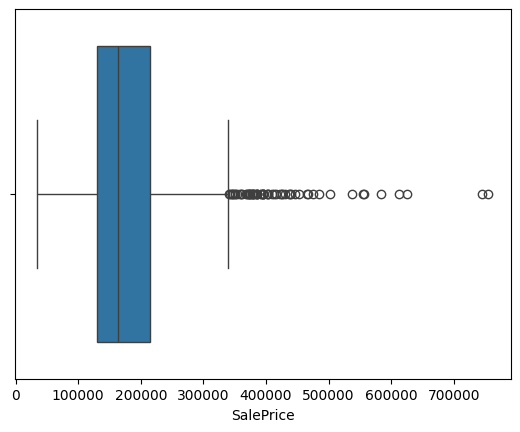

In [90]:
sns.boxplot(x=df["SalePrice"])
plt.show()

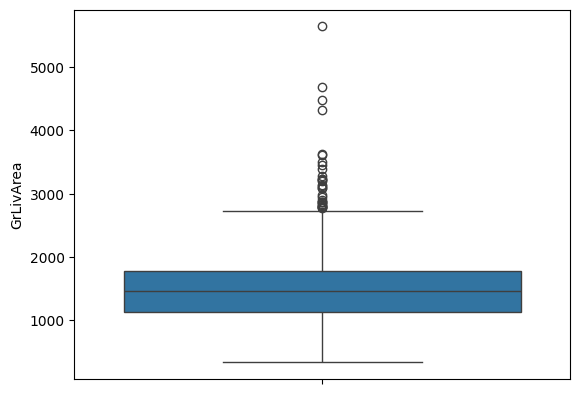

In [91]:
sns.boxplot(df['GrLivArea'])
plt.show()

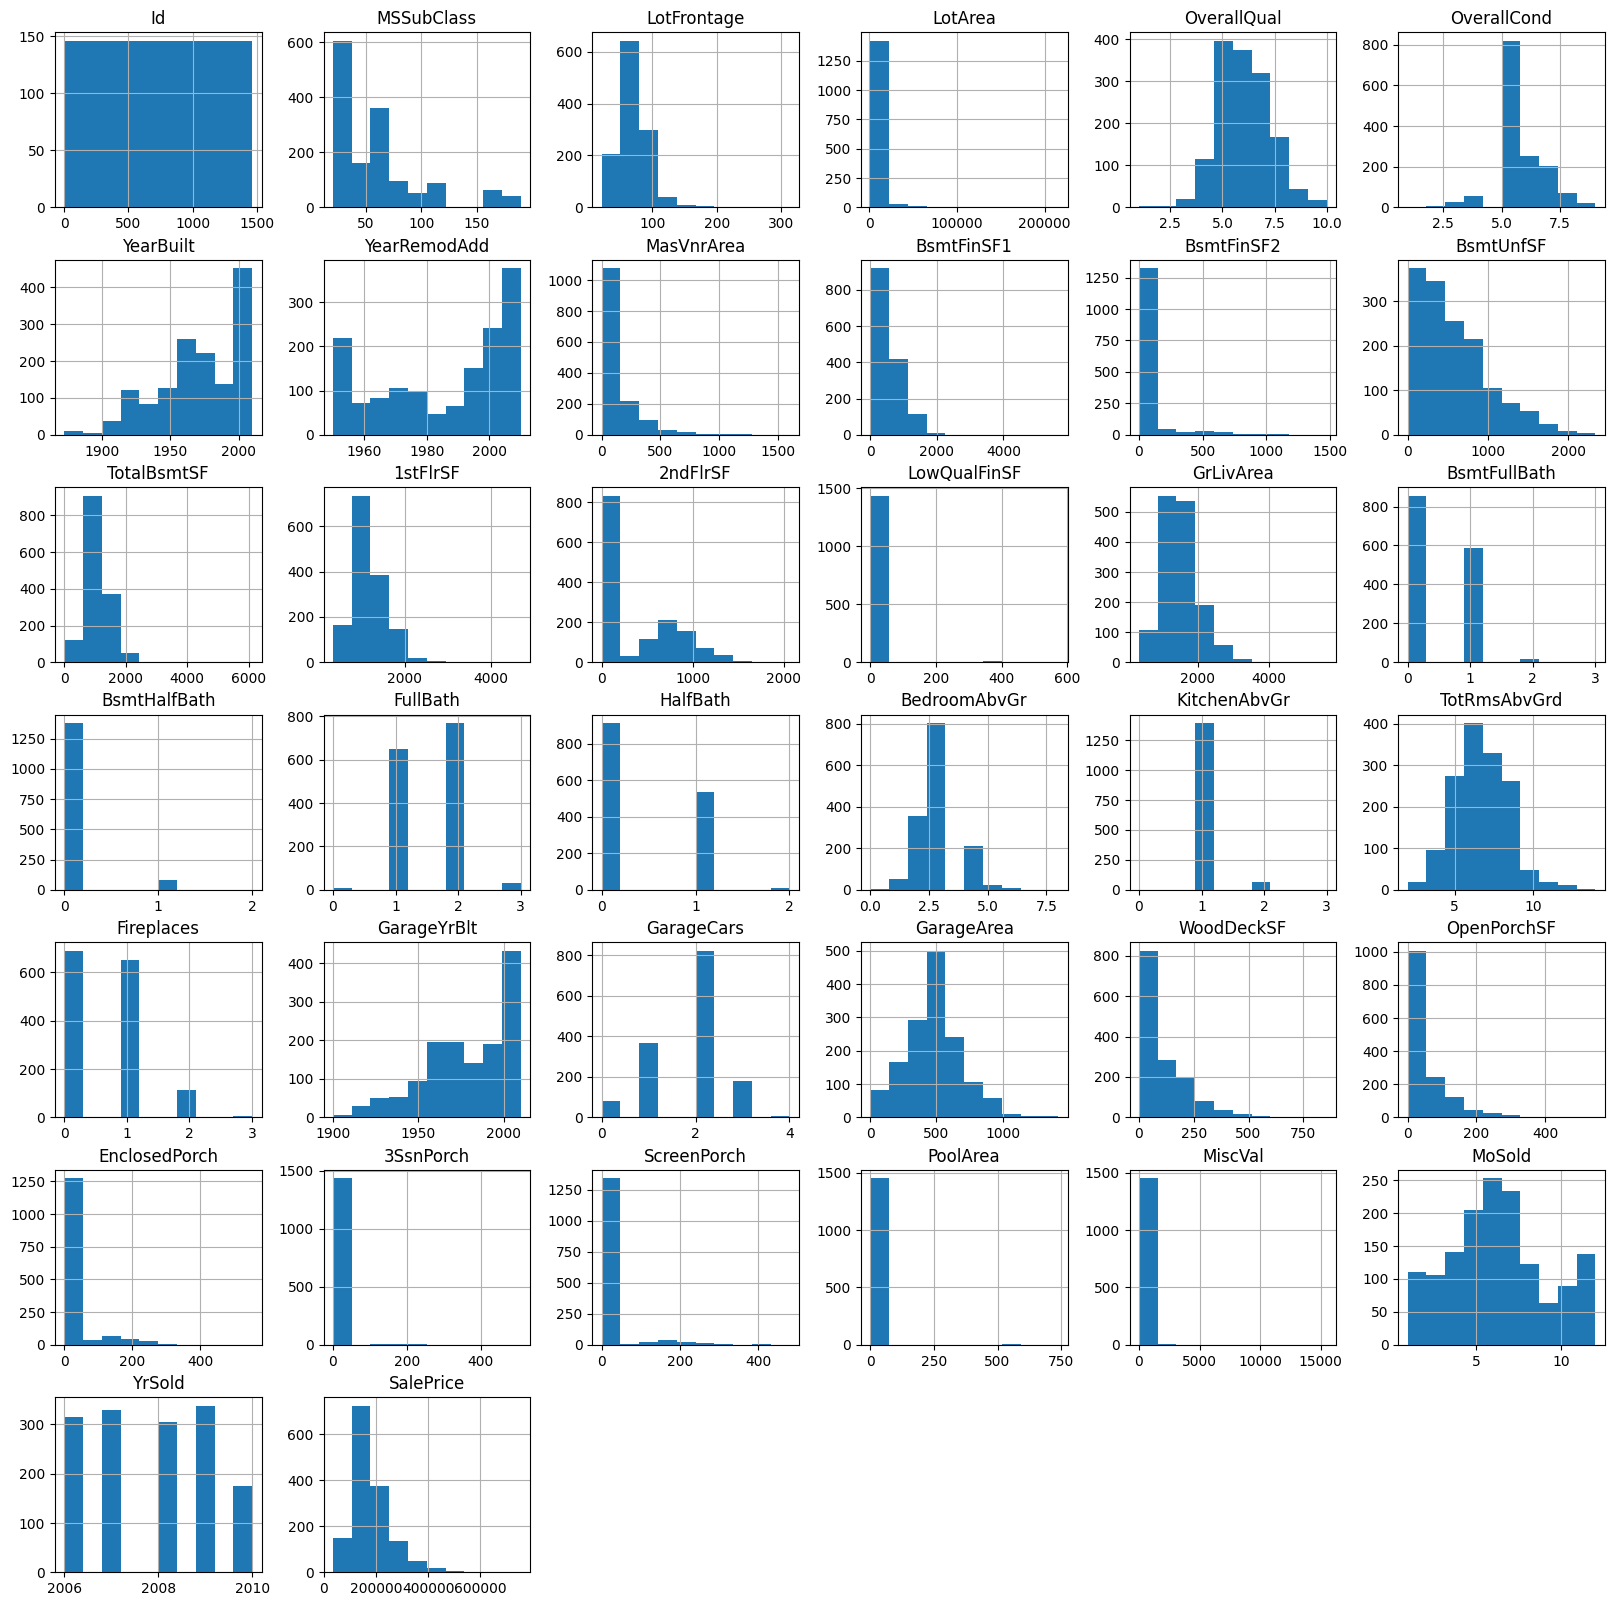

In [92]:
df.hist(figsize=(20,20))
plt.show()

In [93]:
train_clean = df.copy()
test_clean = test.copy()

In [94]:
missing = train_clean.isnull().sum()
missing[missing>0].sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

In [95]:
missing = train_clean.isnull().mean()*100
missing[missing>0].sort_values(ascending=False)

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
BsmtExposure     2.602740
BsmtFinType2     2.602740
BsmtQual         2.534247
BsmtCond         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64

In [96]:
df["MasVnrArea"].skew()

np.float64(2.669084210182863)

I'll go feature by feature to handle missing values first with PoolQC
so we'll see if poolqc really means that the pool is absent by using the pool area data as a comparison.

In [97]:
train_clean[train_clean['PoolArea']>0][['PoolArea','PoolQC']].isna().sum()

PoolArea    0
PoolQC      0
dtype: int64

In [98]:
missing = train_clean.isnull().mean()*100
missing[missing>0].sort_values(ascending=False)

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
BsmtExposure     2.602740
BsmtFinType2     2.602740
BsmtQual         2.534247
BsmtCond         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64

as we can see all the NA in poolqc means that the pool is absent

In [99]:
cols = [
    "PoolQC",
    "MiscFeature",
    "Alley",
    "Fence",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "BsmtExposure",
    "BsmtQual",
    "BsmtCond",
    "BsmtFinType1",
    "BsmtFinType2",
    "GarageYrBlt"
]

for col in cols:
    train_clean[col] = train_clean[col].fillna("NA")
    test_clean[col] = test_clean[col].fillna("NA")

In [100]:
lotfrontage_median = train_clean['LotFrontage'].median()
train_clean['LotFrontage'] = train_clean['LotFrontage'].fillna(lotfrontage_median)
test_clean['LotFrontage'] = test_clean['LotFrontage'].fillna(lotfrontage_median)

In [101]:
train_clean[(train_clean["GarageType"].values !="NA") & (train_clean["GarageType"].values =="None")][['GarageType','GarageYrBlt']]

,GarageType,GarageYrBlt


In [102]:
train_clean.loc[(train_clean['MasVnrArea'].notna()) & (train_clean['MasVnrType'].isna()), 'MasVnrType'] = "None"
test_clean.loc[(test_clean['MasVnrArea'].notna()) & (test_clean['MasVnrType'].isna()),'MasVnrType'] = "None"

In [103]:
train_clean['MasVnrArea'] = train_clean['MasVnrArea'].fillna(0)
test_clean['MasVnrArea'] = test_clean['MasVnrArea'].fillna(0)

masVnrTypemode = train_clean['MasVnrType'].mode()[0]
train_clean['MasVnrType'] = train_clean['MasVnrType'].fillna(masVnrTypemode)
test_clean['MasVnrType'] = test_clean['MasVnrType'].fillna(masVnrTypemode)

electricalMode = train_clean['Electrical'].mode()[0]
train_clean['Electrical'] = train_clean['Electrical'].fillna(electricalMode)
test_clean['Electrical'] = test_clean['Electrical'].fillna(electricalMode)


In [104]:
numeric_cols = train_clean.select_dtypes(include=['number']).columns.tolist()
print(numeric_cols)

['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']


In [105]:
candidate_cols = []
for col in numeric_cols:
    if train_clean[col].nunique() < 10:
        continue
    zero_fraction = (train_clean[col]==0).mean()
    if zero_fraction > 0.8:
        continue
    corr = train_clean[[col,'SalePrice']].corr().iloc[0,1]
    if abs(corr) < 0.1:
        continue
    candidate_cols.append(col)
    manual_include = ['YearBuilt', 'BedroomAbvGr', 'FullBath', 'Fireplaces']
    for col in manual_include:
        if col in numeric_cols and col not in candidate_cols:
            candidate_cols.append(col)
candidate_cols    

['LotFrontage',
 'YearBuilt',
 'BedroomAbvGr',
 'FullBath',
 'Fireplaces',
 'LotArea',
 'OverallQual',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'GrLivArea',
 'TotRmsAbvGrd',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'SalePrice']

In [106]:
# Remove duplicates while preserving order
candidate_cols = list(dict.fromkeys(candidate_cols))

# Optional: remove SalePrice if you don't want to detect outliers in the target
candidate_cols.remove('SalePrice')
candidate_cols

['LotFrontage',
 'YearBuilt',
 'BedroomAbvGr',
 'FullBath',
 'Fireplaces',
 'LotArea',
 'OverallQual',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'GrLivArea',
 'TotRmsAbvGrd',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF']

In [107]:
summary_outlier = []
for col in candidate_cols:
    q1 = train_clean[col].quantile(0.25)
    q3 = train_clean[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr

    outliers = train_clean[((train_clean[col]<lower)  | (train_clean[col] > upper))]
    if lower > 0:
        summary_outlier = f"{col:20s}: {len(outliers):5d} outliers   (bounds: {lower:.2f}, {upper:.2f})"
        print(summary_outlier)

LotFrontage         :   106 outliers   (bounds: 31.50, 107.50)
YearBuilt           :     7 outliers   (bounds: 1885.00, 2069.00)
BedroomAbvGr        :    35 outliers   (bounds: 0.50, 4.50)
LotArea             :    69 outliers   (bounds: 1481.50, 17673.50)
OverallQual         :     2 outliers   (bounds: 2.00, 10.00)
YearRemodAdd        :     0 outliers   (bounds: 1911.50, 2059.50)
TotalBsmtSF         :    61 outliers   (bounds: 42.00, 2052.00)
1stFlrSF            :    20 outliers   (bounds: 118.12, 2155.12)
GrLivArea           :    31 outliers   (bounds: 158.62, 2747.62)
TotRmsAbvGrd        :    30 outliers   (bounds: 2.00, 10.00)


In [108]:
import numpy as np

skewed_cols = ['LotFrontage', 'LotArea', 'TotalBsmtSF', 'GrLivArea']
for col in skewed_cols:
    train_clean[f'{col}_log'] = np.log1p(train_clean[col])
    test_clean[f'{col}_log'] = np.log1p(test_clean[col])


In [109]:
# Look at years before 1900 or after current year+5
train_clean[(train_clean['YearBuilt'] < 1900) | (train_clean['YearBuilt'] > 2025)][['YearBuilt', 'SalePrice', 'Neighborhood']]

,YearBuilt,SalePrice,Neighborhood
106,1885,100000,OldTown
185,1892,475000,OldTown
304,1880,295000,OldTown
583,1893,325000,OldTown
630,1880,124000,OldTown
716,1890,159500,OldTown
747,1880,265979,OldTown
809,1898,106000,OldTown
945,1890,124900,OldTown
991,1882,168000,OldTown


In [110]:
# Cap at 5 bedrooms (beyond that is rare)
train_clean['BedroomAbvGr_capped'] = train_clean['BedroomAbvGr'].clip(upper=5)
test_clean['BedroomAbvGr_capped'] = test_clean['BedroomAbvGr'].clip(upper=5)
# Cap total rooms at 12
train_clean['TotRmsAbvGrd_capped'] = train_clean['TotRmsAbvGrd'].clip(upper=12)
test_clean['TotRmsAbvGrd_capped'] = test_clean['TotRmsAbvGrd'].clip(upper=12)

In [111]:
train_clean[train_clean['1stFlrSF'] > 4000][['1stFlrSF', 'SalePrice', 'Neighborhood']]

,1stFlrSF,SalePrice,Neighborhood
1298,4692,160000,Edwards


In [112]:
from scipy import stats

# Linear regression between GrLivArea and SalePrice
slope, intercept, r_value, p_value, std_err = stats.linregress(
    train_clean['GrLivArea'], train_clean['SalePrice']
)
residual = train_clean['SalePrice'] - (intercept + slope * train_clean['GrLivArea'])
residual_z = (residual - residual.mean()) / residual.std()

# Flag points where residual is more than 3 standard deviations away
train_clean['multivariate_outlier'] = abs(residual_z) > 3

# Inspect flagged rows
multivariate_outliers = train_clean[train_clean['multivariate_outlier']]
print(multivariate_outliers[['GrLivArea', 'SalePrice', 'OverallQual', 'Neighborhood']])

      GrLivArea  SalePrice  OverallQual Neighborhood
53         1842     385000            9      Veenker
151        1710     372402            8      NridgHt
178        2234     501837            9      StoneBr
278        2121     415298            9      NridgHt
378        1856     394432            9      StoneBr
440        2402     555000           10      NridgHt
473        1976     440000            8      NridgHt
523        4676     184750           10      Edwards
591        2296     451950           10      NridgHt
635        3395     200000            6        SWISU
664        2097     423000            8      Somerst
688        1419     392000            8      StoneBr
691        4316     755000           10      NoRidge
803        2822     582933            9      NridgHt
898        2364     611657            9      NridgHt
987        1940     395192            9      NridgHt
1046       2868     556581            9      StoneBr
1062       2337      90000            5      O

In [113]:
# Define rows that are almost certainly errors (based on your judgment)
error_indices = [523, 1298]   # add 1062 if you confirm it's an error
train_clean = train_clean.drop(index=error_indices)

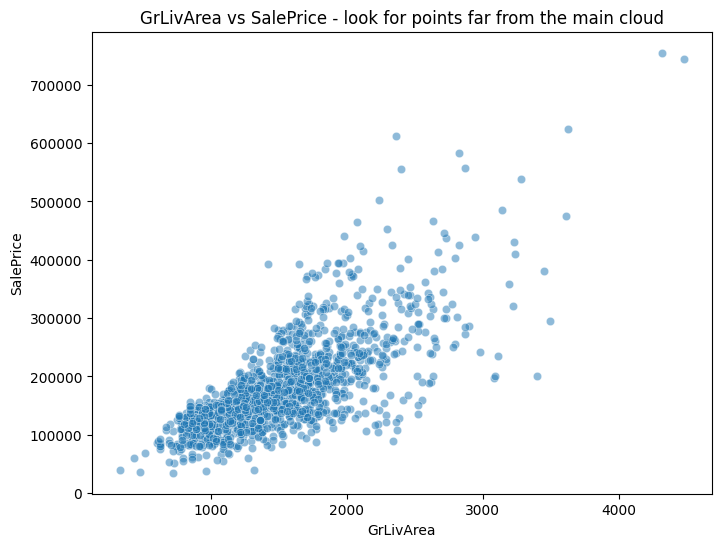

In [114]:
# Look at pairs that are highly correlated (we'll compute correlation next)
# Example: GrLivArea vs SalePrice
plt.figure(figsize=(8,6))
sns.scatterplot(x=train_clean['GrLivArea'], y=train_clean['SalePrice'], alpha=0.5)
plt.xlabel('GrLivArea'); plt.ylabel('SalePrice')
plt.title('GrLivArea vs SalePrice - look for points far from the main cloud')
plt.show()

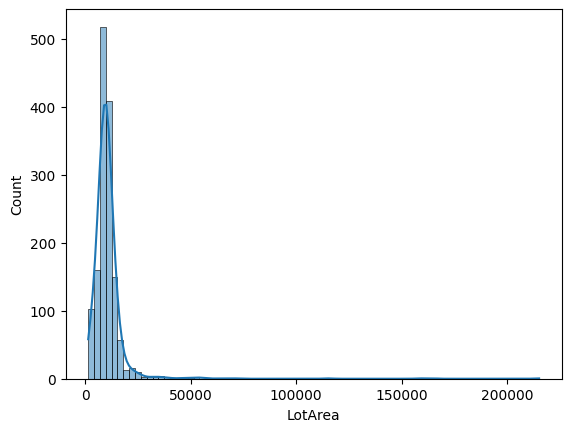

In [115]:
sns.histplot(df['LotArea'],kde=True)
plt.show()

In [116]:
train_clean.to_csv('../data/processed/cleaned_train.csv',index=False)
test_clean.to_csv('../data/processed/cleaned_test.csv', index=False)

# Feature Engineering Continues here 

In [117]:
y = np.log1p(train_clean["SalePrice"])

train_clean.drop("SalePrice", axis=1, inplace=True)

In [118]:
full_df = pd.concat([train_clean, test_clean], axis=0)

In [119]:
num_cols = full_df.select_dtypes(include=np.number).columns
cat_cols = full_df.select_dtypes(exclude=np.number).columns

In [120]:
full_df["TotalBath"] = (
    full_df["FullBath"] +
    0.5 * full_df["HalfBath"] +
    full_df["BsmtFullBath"] +
    0.5 * full_df["BsmtHalfBath"]
)

In [121]:
full_df["HouseAge"] = (
    full_df["YrSold"] -
    full_df["YearBuilt"]
)

In [122]:
full_df["TotalPorchSF"] = (
    full_df["OpenPorchSF"] +
    full_df["EnclosedPorch"] +
    full_df["3SsnPorch"] +
    full_df["ScreenPorch"]
)

In [123]:
full_df = pd.get_dummies(full_df, drop_first=True)

In [124]:
X_train = full_df.iloc[:len(y), :].copy()

X_test = full_df.iloc[len(y):, :].copy()

In [125]:
print(X_train.shape)

print(X_test.shape)

print(y.shape)
assert X_test.shape[0] == test.shape[0], "Test shape must equal original test rows"

(1458, 371)
(1459, 371)
(1458,)


In [126]:
X_train.to_csv("../data/processed/X_train_processed.csv", index=False)

X_test.to_csv("../data/processed/X_test_processed.csv", index=False)

# Model Training

In [127]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score


In [128]:
X_train_split, X_valid, y_train_split, y_valid = train_test_split(
    X_train,
    y,
    test_size=0.2,
    random_state=42
)

In [129]:
print(X_train_split.shape)
print(X_valid.shape)
print(y_train_split.shape)
print(y_valid.shape)

(1166, 371)
(292, 371)
(1166,)
(292,)


In [130]:
lr_model = LinearRegression()

lr_model.fit(X_train_split, y_train_split)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [131]:
lr_preds = lr_model.predict(X_valid)

In [132]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [133]:
mae = mean_absolute_error(y_valid, lr_preds)

print(mae)

0.09125028707417673


In [134]:
lr_rmse = np.sqrt(
    mean_squared_error(y_valid, lr_preds)
)

print(lr_rmse)

0.14220511835253793


In [135]:
lr_r2 = r2_score(y_valid, lr_preds)

print(lr_r2)

0.8800406699116835


In [136]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_split, y_train_split)

rf_preds = rf_model.predict(X_valid)

In [137]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    verbosity=0

)

xgb_model.fit(
    X_train_split,
    y_train_split
)

xgb_preds = xgb_model.predict(X_valid)

In [138]:
rf_rmse = np.sqrt(
    mean_squared_error(y_valid, rf_preds)
)

rf_r2 = r2_score(y_valid, rf_preds)

print("Random Forest RMSE:", rf_rmse)
print("Random Forest R2:", rf_r2)

Random Forest RMSE: 0.147308997011662
Random Forest R2: 0.8712752311673467


In [139]:
xgb_rmse = np.sqrt(
    mean_squared_error(y_valid, xgb_preds)
)

xgb_r2 = r2_score(y_valid, xgb_preds)

print("XGBoost RMSE:", xgb_rmse)
print("XGBoost R2:", xgb_r2)

XGBoost RMSE: 0.12948744681534627
XGBoost R2: 0.9005376053820905


In [140]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    
    "RMSE": [
        lr_rmse,
        rf_rmse,
        xgb_rmse
    ],
    
    "R2 Score": [
        lr_r2,
        rf_r2,
        xgb_r2
    ]
})

results

,Model,RMSE,R2 Score
0,Linear Regression,0.142205,0.880041
1,Random Forest,0.147309,0.871275
2,XGBoost,0.129487,0.900538


In [141]:
train_preds = xgb_model.predict(X_train_split)

train_rmse = np.sqrt(
    mean_squared_error(
        y_train_split,
        train_preds
    )
)

print(train_rmse)

0.02297923525937288


In [142]:
FinalModel = XGBRegressor()
FinalModel.fit(X_train,y)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [143]:
test_preds = FinalModel.predict(X_test)

In [144]:
test_preds = np.expm1(test_preds)

In [145]:
submission = pd.DataFrame({
    "Id":test['Id'],
    "SalePrice":test_preds
    })
submission.head()

,Id,SalePrice
0,1461,122535.429688
1,1462,167206.515625
2,1463,197282.140625
3,1464,193339.812500
4,1465,199678.281250


In [146]:
submission.to_csv('../data/processed/submission.csv',index=False)

In [147]:
import joblib

joblib.dump(FinalModel,'../models/house_price_model.pkl')

['../models/house_price_model.pkl']